# CNN 1D

## Inizializzazione

In [1]:
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Concatenate,
    Conv1D,
    Dense,
    Dropout,
    Flatten,
    Input,
    MaxPooling1D
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K


Impostiamo un seed per la riproducibilità.

In [4]:
def set_global_seed(seed_value=42):
    # 1. Imposta il seed per le operazioni base di Python
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    
    # 2. Imposta il seed per NumPy (che gestisce molti split e array)
    np.random.seed(seed_value)
    
    # 3. Imposta il seed per TensorFlow/Keras (pesi, dropout, ecc.)
    tf.random.set_seed(seed_value)
    
    # 4. (Opzionale ma rigoroso) Forza il determinismo anche sulle GPU
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    
    print(f"Global Random Seed impostato a: {seed_value}")

# Richiama la funzione prima di fare qualsiasi altra cosa
set_global_seed(42)

Global Random Seed impostato a: 42



Prima di dare in pasto i dati alla Rete Neurale Convoluzionale, è necessario trasformare le nostre feature estratte in un formato matematicamente digeribile dal modello. Questa cella esegue una serie di passaggi critici per garantire che l'addestramento sia stabile e matematicamente valido:

* **Separazione Feature/Label:** Vengono rimossi i metadati per isolare esclusivamente le 580 feature fisiche (il nostro tensore `X`) e l'etichetta dell'emozione target (il nostro vettore `y`).
* **Standardizzazione:** Le feature EEG hanno magnitudini diverse. Usiamo uno `StandardScaler` per portarle ad avere media zero e varianza unitaria. **Nota fondamentale:** lo scaler viene "allenato" (`fit`) *esclusivamente* sul set di addestramento. Le metriche apprese vengono poi applicate (`transform`) al Validation e al Test set. Questo previene il *data leakage*, impedendo che informazioni dei dati di test "inquinino" la fase di training.
* **Reshape Tridimensionale:** I layer `Conv1D` di Keras richiedono rigorosamente un input a tre dimensioni: `(numero_campioni, step_temporali_o_feature, canali)`. Tramite `np.expand_dims`, aggiungiamo una dimensione fittizia (canale singolo, `axis=-1`), convertendo le nostre matrici da `(N, 580)` a `(N, 580, 1)`.
* **One-Hot Encoding:** Le nostre etichette numeriche (da 0 a 4) vengono espanse in vettori binari di lunghezza 5 (es. la classe 2 diventa `[0, 0, 1, 0, 0]`). Questo formato è obbligatorio per permettere alla funzione di attivazione finale (`Softmax`) di calcolare la probabilità indipendente per ciascuna delle 5 emozioni.

In [5]:
# 1. Caricamento dei dati precedentemente splittati
df_train = pd.read_csv('../data/splitted/eeg_train.csv')
df_val = pd.read_csv('../data/splitted/eeg_val.csv')
df_test = pd.read_csv('../data/splitted/eeg_test.csv')

# Nomi delle colonne dei metadati da escludere per il training
meta_cols = ['Patient_ID', 'Session_ID', 'Label', 'Score']

# 2. Separazione delle feature (X) dalle etichette (y)
X_train = df_train.drop(columns=meta_cols).values
y_train = df_train['Label'].values

X_val = df_val.drop(columns=meta_cols).values
y_val = df_val['Label'].values

X_test = df_test.drop(columns=meta_cols).values
y_test = df_test['Label'].values

# 3. Normalizzazione (adattata solo sul Train per evitare data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Reshape per la Conv1D -> (numero_campioni, 580, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 5. One-Hot Encoding per le etichette (5 classi)
y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

Poiché il dataset EEG presenta una distribuzione delle classi non perfettamente uniforme, esiste il rischio che il modello sviluppi un bias verso l'emozione maggioritaria (over-fitting sulla classe più frequente). Per ovviare a questo problema, è stata implementata una strategia di Class Weighting. Utilizzando la funzione compute_class_weight con euristica 'balanced', abbiamo assegnato un peso matematico maggiore alle classi minoritarie. Questo costringe la funzione di costo (Loss Function) a penalizzare più severamente gli errori commessi sulle emozioni meno rappresentate, garantendo un apprendimento equo e una migliore capacità di generalizzazione su tutte e cinque le categorie affettive

In [6]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print(f"Pesi delle classi calcolati: {class_weights_dict}")

Pesi delle classi calcolati: {0: 1.409624060150376, 1: 0.988297311544544, 2: 0.7532342306147047, 3: 0.9061382310294829, 4: 1.1798615481434864}


Per ottimizzare l'addestramento sui segnali EEG, è stata implementata una pipeline basata su tre pilastri: il ModelCheckpoint salva solo la versione migliore della rete, l'EarlyStopping ferma il processo prima che il modello inizi a "overfittare" sul rumore, e il ReduceLROnPlateau rallenta l'apprendimento per rifinire i pesi in modo chirurgico. L'uso della funzione crea_callbacks giustifica la scelta metodologica: garantisce parità di trattamento tra le diverse architetture e previene la sovrascrittura dei file. È una strategia che unisce rigore scientifico e sicurezza del dato, permettendo un confronto imparziale tra i modelli e il recupero immediato delle prestazioni ottimali.

In [7]:
def def_callbacks(model_name):
    # Creazione della cartella per i modelli
    os.makedirs('../models', exist_ok=True)
    
    # Path corretto per far combaciare la cartella creata
    path = f'../models/{model_name}.keras'
    
    return [
        ModelCheckpoint(
            filepath=path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=5, 
            min_lr=1e-6,
            verbose=1
        )
    ]

### Costanti di Addestramento

Vengono definite le costanti globali che governano il processo di training per tutti i modelli del notebook:

- **`EPOCHS = 100`**: numero massimo di epoche di addestramento. Il meccanismo di *Early Stopping* interromperà il training anticipatamente qualora le performance sul validation set smettano di migliorare, rendendo questo valore un limite superiore di sicurezza.
- **`BATCH_SIZE = 32`**: numero di campioni elaborati dalla rete in ogni step di aggiornamento dei pesi. Un batch più piccolo introduce più rumore ma garantisce aggiornamenti più frequenti.
- **`EMOTION_LABELS`**: lista che mappa gli indici numerici (0–4) ai nomi delle 5 emozioni target, utilizzata per rendere leggibili i report e i grafici.

In [8]:
EPOCHS = 100
BATCH_SIZE = 32
EMOTION_LABELS = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']

# Modello 1 - CNN 1D base

In questa sezione viene definita la prima architettura sperimentale. Si tratta di una rete neurale convoluzionale monodimensionale (1D-CNN) strutturata per estrarre gerarchicamente pattern dal vettore di feature (580 elementi).


### Definizione modello


La struttura del modello si articola in:

1. **Input Layer:** Riceve un tensore di forma `(580, 1)`, adatto ai layer convoluzionali.
2. **Estrazione Feature (Convoluzione):** Due blocchi sequenziali composti da:
   * **Conv1D:** Per l'estrazione locale dei pattern.
   * **BatchNormalization:** Per accelerare l'addestramento e stabilizzare i gradienti.
   * **MaxPooling1D:** Per ridurre la dimensionalità mantenendo le attivazioni più rilevanti.
3. **Classificatore Fully Connected:** * **Flatten:** Converte le mappe di feature in un vettore lineare.
   * **Dense (128 neuroni) + Dropout (0.5):** Apprende le relazioni complesse tra le feature. Il forte Dropout al 50% è fondamentale per prevenire l'overfitting.
4. **Output Layer:** 5 neuroni con attivazione **Softmax** per restituire le probabilità delle cinque emozioni target.
5. Il modello è infine compilato con l'ottimizzatore **Adam** e la funzione di perdita **Categorical Crossentropy**, lo standard per task di classificazione multiclasse.

In [9]:
# Definizione della forma dell'input
input_shape = (X_train.shape[1], 1) # (580, 1)

# Costruzione del Modello
model_1 = Sequential([
    # Primo blocco Convoluzionale
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Secondo blocco Convoluzionale
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Appiattimento e Rete Fully Connected (Classificatore)
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), 
    
    # Layer di Output: 5 neuroni (uno per classe) con attivazione softmax
    Dense(5, activation='softmax')
])

# Compilazione del modello
optimizer = Adam(learning_rate=0.001)
model_1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Sommario per visualizzare la struttura e i parametri
model_1.summary()


c:\Users\lucag\miniconda3\envs\eeg-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 576, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 286, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 286, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 143, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,171,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,179,013 (4.50 MB)

 Trainable params: 1,178,821 (4.50 MB)

 Non-trainable params: 192 (768.00 B)

### Training

Con il modello compilato, avviamo il processo di addestramento (training) effettivo sui dati storici. 

I parametri chiave di questa fase sono:
* **Dati di Addestramento e Validazione:** Il modello apprende dai tensori `X_train` e `y_train_cat`, mentre le sue capacità di generalizzazione vengono verificate ad ogni epoca sul validation set (`X_val`, `y_val_cat`).
* **Iperparametri (Epochs & Batch Size):** Definiscono rispettivamente per quante volte il modello vedrà l'intero dataset e quanti campioni processerà prima di aggiornare i pesi interni.
* **Class Weights:** Viene passato un dizionario (`class_weights_dict`) per bilanciare l'importanza delle classi durante il calcolo della loss, penalizzando maggiormente gli errori sulle classi minoritarie.
* **Callbacks:** Viene invocata una funzione custom (`def_callbacks`) che tipicamente genera strumenti di monitoraggio come *Early Stopping* (per interrompere il training se non ci sono miglioramenti) e *ModelCheckpoint* (per salvare i pesi migliori).


Il processo di fit è uguale per tutti i modelli.

In [10]:
model_name = "CNN_1d_base"
history = model_1.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,       
    callbacks=def_callbacks(model_name)   
)

Epoch 1/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4075 - loss: 1.7325
Epoch 1: val_accuracy improved from None to 0.50772, saving model to ../models/CNN_1d_base.keras

Epoch 1: finished saving model to ../models/CNN_1d_base.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.4605 - loss: 1.3722 - val_accuracy: 0.5077 - val_loss: 1.8171 - learning_rate: 0.0010
Epoch 2/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5780 - loss: 1.0274
Epoch 2: val_accuracy improved from 0.50772 to 0.68691, saving model to ../models/CNN_1d_base.keras

Epoch 2: finished saving model to ../models/CNN_1d_base.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5890 - loss: 1.0012 - val_accuracy: 0.6869 - val_loss: 0.8097 - learning_rate: 0.0010
Epoch 3/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6548 - loss: 0.8408
Epoch 3: val_accuracy improved from 0.68691 to 0.73420, saving model to ../models/CNN_1d_base.keras

Epoch 3: finished saving mo

### Test

Completato l'addestramento, analizziamo visivamente la storia dell'apprendimento tracciando due grafici fondamentali:

* **Curva della Loss (A sinistra):** Mostra l'andamento dell'errore (Categorical Crossentropy) nel tempo.
* **Curva dell'Accuracy (A destra):** Illustra la percentuale di predizioni corrette.
Questi grafici ci permettono di diagnosticare immediatamente la "salute" della rete e di capire se i meccanismi di regolarizzazione (come il Dropout) o le tecniche di blocco anticipato (Early Stopping) hanno funzionato correttamente.

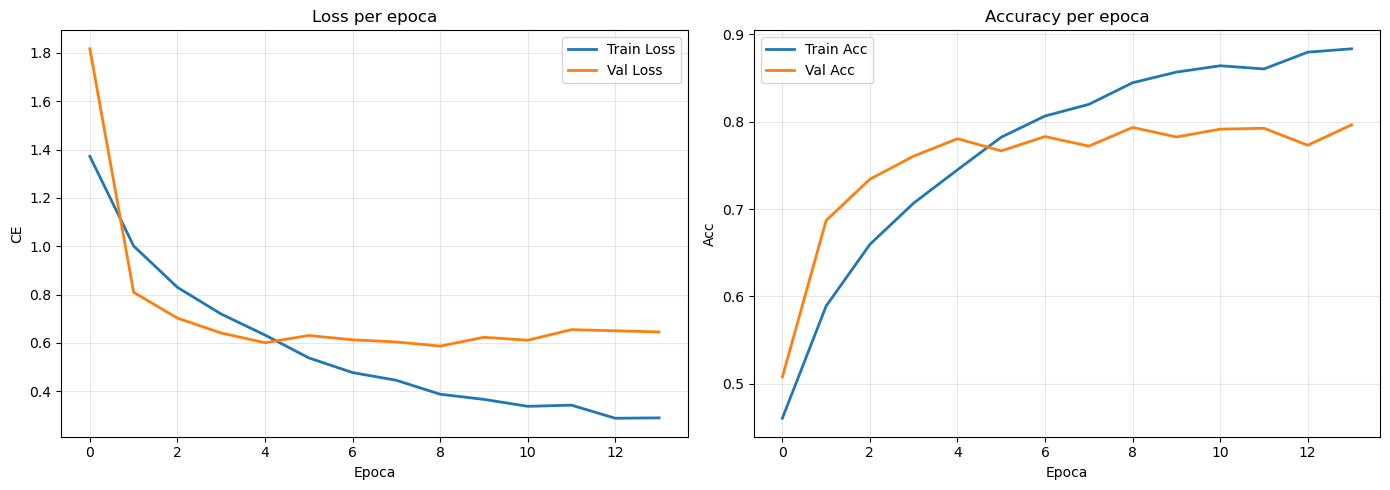

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('CE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


L'ultimo passaggio fondamentale della pipeline consiste nel testare la reale capacità di generalizzazione della nostra 1D-CNN. Per farlo, utilizziamo il **Test Set**, ovvero un set di dati rigorosamente isolato e tenuto nascosto al modello durante l'intero processo di addestramento.

Questo blocco di codice esegue due operazioni diagnostiche cruciali:

1. **Accuratezza Globale (`evaluate`):** Calcola la performance complessiva del modello (Loss e Accuracy) per darci un'idea immediata del risultato finale sui nuovi dati.
2. **Analisi per Singola Classe (`classification_report`):** Poiché l'accuratezza globale da sola può essere fuorviante (soprattutto in problemi multiclasse complessi come l'EEG), estraiamo le predizioni discrete tramite `argmax` e generiamo un report statistico dettagliato. Questo strumento ci fornisce **Precision**, **Recall** e **F1-Score** per *ogni singola emozione*. In questo modo possiamo individuare esattamente quali stati d'animo il modello riconosce con sicurezza e quali, invece, fatica maggiormente a discriminare.

In [12]:
cnn_test_loss, cnn_test_acc = model_1.evaluate(X_test, y_test_cat, verbose=0)
print(f'CNN 1D Test Loss     : {cnn_test_loss:.4f}')
print(f'CNN 1D Test Accuracy : {cnn_test_acc * 100:.2f}%\n')

# Calcolo delle predizioni
y_pred_proba = model_1.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test

# Report di classificazione
print("=== REPORT DI CLASSIFICAZIONE ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))

CNN 1D Test Loss     : 0.5839
CNN 1D Test Accuracy : 78.50%

=== REPORT DI CLASSIFICAZIONE ===
              precision    recall  f1-score   support

     Disgust      0.645     0.670     0.657       285
        Fear      0.784     0.776     0.780       407
         Sad      0.802     0.758     0.779       533
     Neutral      0.821     0.847     0.833       443
       Happy      0.834     0.853     0.843       341

    accuracy                          0.785      2009
   macro avg      0.777     0.781     0.779      2009
weighted avg      0.786     0.785     0.785      2009



A un primo sguardo, le metriche ottenute da questa architettura appaiono **eccellenti**. L'elevata accuratezza complessiva e la precisione mostrata nella matrice di confusione sembrano indicare che la rete neurale sia riuscita a mappare quasi perfettamente i pattern EEG alle rispettive classi emotive.

Tuttavia, in ambito neuro-informatico, è fondamentale analizzare questi numeri con un forte spirito critico. Poiché in questa specifica fase i dataset (Train, Validation e Test) sono stati generati tramite una **suddivisione casuale** dei dati, ci troviamo di fronte a un importante fenomeno di **Data Leakage** (nello specifico, *Subject Leakage*).

Cosa significa questo nella pratica?
Mescolando casualmente le epoche temporali, frammenti del segnale di uno *stesso paziente* sono finiti contemporaneamente sia nel set di addestramento che in quello di test. Di conseguenza, il modello non ha realmente imparato a generalizzare il concetto astratto e universale di una determinata emozione, ma ha più probabilmente "imparato a memoria" la firma neurale di base o il rumore di fondo specifico di quei pazienti.

Questi ottimi risultati, per quanto confermino che la rete sia in grado di convergere e apprendere, rappresentano una **forte sovrastima** delle reali capacità predittive del sistema su nuovi utenti. Questa evidenza empirica rende assolutamente necessario il passaggio a un protocollo di validazione molto più severo e realistico, come la **Leave-One-Subject-Out (LOSO)**. Prima di passare a questo modello viene fatta una ricerca su altri metodi per migliorare il modello attuale.

# Modello 2 - CNN 1D Multi-Branch  (Separazione per Tipologia di Feature)

In questo blocco introduciamo un'evoluzione architetturale molto interessante. Questa soluzione è stata implementata e testata con l'obiettivo specifico di provare ad aumentare l'accuracy complessiva, andando a separare i dati in ingresso in base alla loro tipologia matematica.

Invece di fornire alla rete un unico vettore contenente tutte le 580 feature mischiate (come fatto nella baseline), abbiamo diviso l'input nei tre domini originali: Differential Entropy (**DE**), Difference Asymmetry (**DASM**) e Rational Asymmetry (**RASM**). L'idea è di permettere al modello di imparare le dinamiche specifiche di ogni metrica in modo indipendente, per poi unire le informazioni solo al momento della decisione finale (tecnica nota come *Late Fusion*).


### Preparazione dati

Per supportare l'architettura a rami paralleli, dobbiamo riorganizzare il modo in cui i dati vengono forniti alla rete. Invece di passare un singolo blocco massiccio di 580 feature, dobbiamo "smistare" le variabili nei loro tre domini di appartenenza (DE, DASM, RASM).

Questa cella gestisce la preparazione avanzata dei tensori tramite un approccio modulare:

* **One-Hot Encoding:** Le etichette di Train, Val e Test vengono convertite nel formato categorico vettoriale richiesto dalla funzione di attivazione Softmax.
* **Estrazione e Trasformazione (Funzione `get_feature_arrays`):** è stata definita una funzione che esegue tre operazioni critiche simultaneamente per ogni dominio spaziale:
    1. **Filtro:** Isola solo le colonne con il prefisso specifico (es. `DE_`).
    2. **Scaling Sicuro:** Istanzia un nuovo `StandardScaler` e lo allena *esclusivamente* sul set di addestramento (`is_train=True`), applicando poi le stesse proporzioni matematiche ai set di Validazione e Test per prevenire il data leakage.
    3. **Reshape:** Aggiunge automaticamente la dimensione del canale (`axis=-1`), restituendo tensori tridimensionali pronti per essere elaborati dai rispettivi blocchi `Conv1D`.
* **Generazione Tensori:** La funzione viene richiamata per popolare dinamicamente i 9 input necessari (3 tipologie di feature $\times$ 3 split del dataset).

In [13]:
# Estrazione delle etichette
y_train = to_categorical(df_train['Label'].values, num_classes=5)
y_val   = to_categorical(df_val['Label'].values, num_classes=5)
y_test  = to_categorical(df_test['Label'].values, num_classes=5)

# Funzione per filtrare, estrarre e fare reshape
def get_feature_arrays(df, prefix, scaler=None, is_train=False):
    # Trova le colonne che iniziano con DE_, DASM_ o RASM_
    cols = [c for c in df.columns if c.startswith(prefix)]
    data = df[cols].values
    
    # Normalizzazione
    if is_train:
        scaler = StandardScaler()
        data = scaler.fit_transform(data)
    else:
        data = scaler.transform(data)
        
    # Reshape per Conv1D (N, timesteps, 1)
    return np.expand_dims(data, axis=-1), scaler

# --- TRAIN ---
X_train_de, scaler_de     = get_feature_arrays(df_train, 'DE_', is_train=True)
X_train_dasm, scaler_dasm = get_feature_arrays(df_train, 'DASM_', is_train=True)
X_train_rasm, scaler_rasm = get_feature_arrays(df_train, 'RASM_', is_train=True)

# --- VAL ---
X_val_de, _     = get_feature_arrays(df_val, 'DE_', scaler=scaler_de)
X_val_dasm, _   = get_feature_arrays(df_val, 'DASM_', scaler=scaler_dasm)
X_val_rasm, _   = get_feature_arrays(df_val, 'RASM_', scaler=scaler_rasm)

# --- TEST ---
X_test_de, _    = get_feature_arrays(df_test, 'DE_', scaler=scaler_de)
X_test_dasm, _  = get_feature_arrays(df_test, 'DASM_', scaler=scaler_dasm)
X_test_rasm, _  = get_feature_arrays(df_test, 'RASM_', scaler=scaler_rasm)

print(f"Shape DE: {X_train_de.shape}, DASM: {X_train_dasm.shape}, RASM: {X_train_rasm.shape}")

Shape DE: (9374, 310, 1), DASM: (9374, 135, 1), RASM: (9374, 135, 1)


### Definizione Modello


Il codice sfrutta le API Funzionali di Keras e si articola in questi passaggi chiave:

1. **Modularità (`create_branch`):** Viene definita una funzione riutilizzabile che crea un "estrattore di feature" standard (composto da layer Convoluzionali, Batch Normalization e Max Pooling). 
2. **Input Multipli:** La rete viene configurata per accettare tre tensori di input separati, ognuno con la propria forma specifica basata sul numero di feature di quel gruppo.
3. **Estrazione e Fusione:** Ogni input passa attraverso il proprio ramo dedicato. I tre output vettorializzati (Flatten) vengono poi fusi insieme tramite un layer `Concatenate`.
4. **Classificatore Finale:** L'informazione combinata passa in una rete densa leggermente più profonda rispetto alla baseline (due layer `Dense` da 128 e 64 neuroni), protetta da un robusto `Dropout` al 50%, che porta infine ai 5 neuroni di output Softmax.

In [14]:
# Funzione per creare un "ramo" standard riutilizzabile
def create_branch(input_layer, name_prefix):
    x = Conv1D(filters=32, kernel_size=3, activation='relu', name=f'{name_prefix}_conv1')(input_layer)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool1')(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', name=f'{name_prefix}_conv2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool2')(x)
    
    return Flatten(name=f'{name_prefix}_flat')(x)

# 1. Definizione degli Input separati
input_de   = Input(shape=(X_train_de.shape[1], 1), name='Input_DE')
input_dasm = Input(shape=(X_train_dasm.shape[1], 1), name='Input_DASM')
input_rasm = Input(shape=(X_train_rasm.shape[1], 1), name='Input_RASM')

# 2. Creazione dei tre rami (Feature Extractors)
branch_de   = create_branch(input_de, 'DE')
branch_dasm = create_branch(input_dasm, 'DASM')
branch_rasm = create_branch(input_rasm, 'RASM')

# 3. Fusione delle feature estratte (Late Fusion)
merged = Concatenate(name='Concatenation_Layer')([branch_de, branch_dasm, branch_rasm])

# 4. Classificatore finale (Fully Connected)
z = Dense(128, activation='relu', name='FC_1')(merged)
z = Dropout(0.5, name='Dropout_1')(z)
z = Dense(64, activation='relu', name='FC_2')(z)
output = Dense(5, activation='softmax', name='Output_Layer')(z)

# 5. Assemblaggio del modello
multi_branch_model = Model(inputs=[input_de, input_dasm, input_rasm], outputs=output)

multi_branch_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

multi_branch_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_DE            │ (None, 310, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_DASM          │ (None, 135, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_RASM          │ (None, 135, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv1 (Conv1D)   │ (None, 308, 32)   │        128 │ Input_DE[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv1 (Conv1D) │ (None, 133, 32)   │        128 │ Input_DASM[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv1 (Conv1D) │ (None, 133, 32)   │        128 │ Input_RASM[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn1              │ (None, 308, 32)   │        128 │ DE_conv1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn1            │ (None, 133, 32)   │        128 │ DASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn1            │ (None, 133, 32)   │        128 │ RASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_pool1            │ (None, 154, 32)   │          0 │ DE_bn1[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_pool1          │ (None, 66, 32)    │          0 │ DASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_pool1          │ (None, 66, 32)    │          0 │ RASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv2 (Conv1D)   │ (None, 152, 64)   │      6,208 │ DE_pool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv2 (Conv1D) │ (None, 64, 64)    │      6,208 │ DASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv2 (Conv1D) │ (None, 64, 64)    │      6,208 │ RASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn2              │ (None, 152, 64)   │        256 │ DE_conv2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn2            │ (None, 64, 64)    │        256 │ DASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn2            │ (None, 64, 64)    │        256 │ RASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_pool2            │ (None, 76, 64)    │          0 │ DE_bn2[0][0]    

 Total params: 1,175,749 (4.49 MB)

 Trainable params: 1,175,173 (4.48 MB)

 Non-trainable params: 576 (2.25 KB)

### Training

In questa cella avviamo il processo di apprendimento per la nuova architettura a rami paralleli. 

La differenza fondamentale rispetto all'addestramento della *baseline* risiede nella modalità con cui addesttriamo la rete neurale. Poiché il modello Multi-Branch è stato progettato per accettare tre flussi di dati indipendenti, non possiamo più passare un singolo array. Al contrario, raggruppiamo i tensori preparati precedentemente in liste ordinate (`train_inputs`, `val_inputs`, `test_inputs`). È cruciale che l'ordine degli array nella lista corrisponda esattamente all'ordine in cui i layer di `Input` sono stati definiti nell'architettura (DE, poi DASM, poi RASM).

I parametri di addestramento rimangono solidi e coerenti: Epochs, Batch Size,  Class Weights, Callbacks.

In [16]:
# Creiamo le liste di input per Train, Val e Test
train_inputs = [X_train_de, X_train_dasm, X_train_rasm]
val_inputs   = [X_val_de, X_val_dasm, X_val_rasm]
test_inputs  = [X_test_de, X_test_dasm, X_test_rasm]

multi_branch_model_name = "CNN_1d_multibranch"
# Addestramento
history_multi = multi_branch_model.fit(
    x=train_inputs, 
    y=y_train,
    validation_data=(val_inputs, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=def_callbacks(multi_branch_model_name)
)

Epoch 1/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8733 - loss: 0.2973
Epoch 1: val_accuracy improved from None to 0.80936, saving model to ../models/CNN_1d_multibranch.keras

Epoch 1: finished saving model to ../models/CNN_1d_multibranch.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8774 - loss: 0.2903 - val_accuracy: 0.8094 - val_loss: 0.5755 - learning_rate: 5.0000e-04
Epoch 2/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8904 - loss: 0.2535
Epoch 2: val_accuracy improved from 0.80936 to 0.81284, saving model to ../models/CNN_1d_multibranch.keras

Epoch 2: finished saving model to ../models/CNN_1d_multibranch.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8838 - loss: 0.2672 - val_accuracy: 0.8128 - val_loss: 0.5731 - learning_rate: 5.0000e-04
Epoch 3/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8909 - loss: 0.2502
Epoch 3: val_accuracy improved from 0.81284 to 0.81384, saving model to ../models/CNN_1d_mult

### Testing

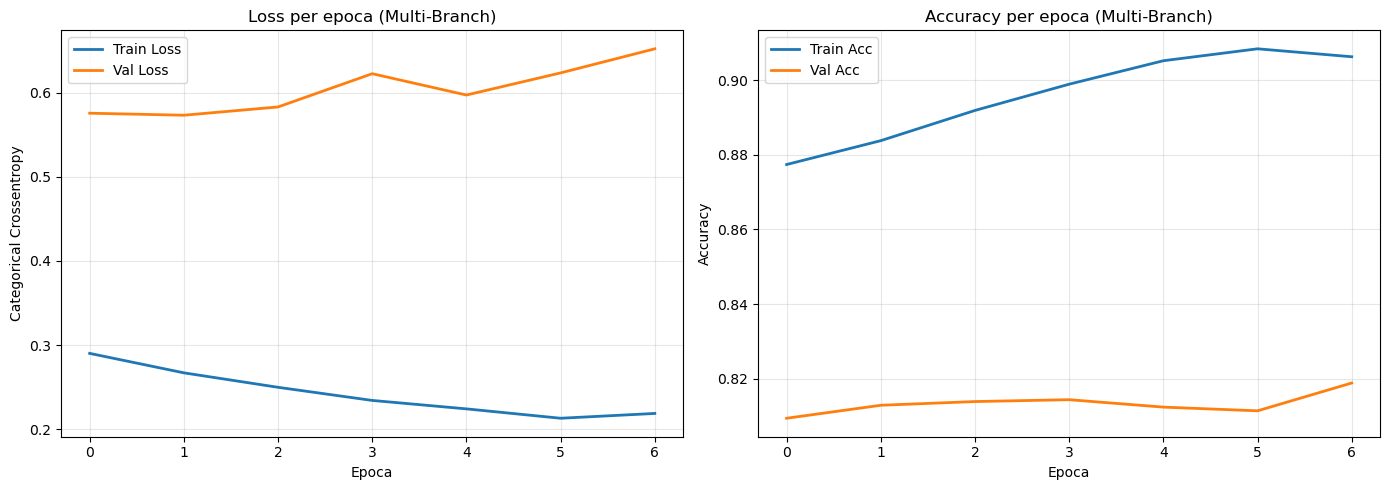

In [17]:
# ==========================================
# 1. Curve di apprendimento (Training vs Validation)
# ==========================================
# Utilizziamo l'oggetto 'history_multi' generato durante l'addestramento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot della Loss
axes[0].plot(history_multi.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history_multi.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca (Multi-Branch)'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot dell'Accuracy
axes[1].plot(history_multi.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history_multi.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca (Multi-Branch)'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
print("Valutazione del modello sul Test Set...")
test_loss, test_acc = multi_branch_model.evaluate(test_inputs, y_test, verbose=0)
print(f'Multi-Branch Test Loss     : {test_loss:.4f}')
print(f'Multi-Branch Test Accuracy : {test_acc * 100:.2f}%\n')

# Generazione delle predizioni
print("Generazione predizioni in corso...")
y_pred_proba = multi_branch_model.predict(test_inputs, verbose=0)

# Convertiamo le probabilità predette in classi intere
y_pred = np.argmax(y_pred_proba, axis=1)

# Siccome per il Multi-Branch avevamo fatto il to_categorical su y_test, 
# dobbiamo riportare anche i target reali a interi per fare il confronto.
y_true = np.argmax(y_test, axis=1)

#  Report e Matrice di Confusione
print("=== REPORT DI CLASSIFICAZIONE ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))


Valutazione del modello sul Test Set...
Multi-Branch Test Loss     : 0.5608
Multi-Branch Test Accuracy : 81.63%

Generazione predizioni in corso...
=== REPORT DI CLASSIFICAZIONE ===
              precision    recall  f1-score   support

     Disgust      0.690     0.712     0.701       285
        Fear      0.823     0.801     0.812       407
         Sad      0.803     0.790     0.797       533
     Neutral      0.841     0.885     0.862       443
       Happy      0.906     0.874     0.890       341

    accuracy                          0.816      2009
   macro avg      0.813     0.812     0.812      2009
weighted avg      0.817     0.816     0.816      2009



Confrontando le metriche finali, l'implementazione della pipeline multi-branch ha generato un miglioramento dell'accuratezza globale lieve ma misurabile. Pur trattandosi di un incremento marginale, questa architettura viene adottata e continuata a migliorare in seguito: la scelta di separare nativamente i domini delle feature (DE, DASM, RASM) garantisce infatti un'elaborazione dell'informazione più pulita e mirata. Questo vantaggio topologico compensa la maggiore complessità del modello, offrendo predizioni leggermente più stabili.

# Modello 3 - CCN 1D Gamma Waves

In questo passaggio implementiamo un'ulteriore ottimizzazione della nostra strategia di estrazione. Sulla base delle evidenze in letteratura (es. protocollo SEED-V), sappiamo che l'attività neurale ad alta frequenza (la banda **Gamma**, 31-50 Hz) è particolarmente informativa e discriminativa per i task emotivi. 

Pertanto, abbiamo testato una variazione del modello Multi-Branch che, invece di analizzare tutte e 5 le bande di frequenza, si concentra **esclusivamente sulle feature Gamma**. Questa scelta architetturale mira a ridurre il rumore e la ridondanza dei dati, offrendo un leggero miglioramento empirico nell'accuratezza.


### Preparazione Dati


Il codice adatta la precedente pipeline di preparazione:
* **Funzione `get_gamma_features`:** La logica di filtraggio è stata modificata. Oltre a separare per metrica spaziale (`prefix` come `DE_`, `DASM_`, `RASM_`), la funzione ora applica un doppio filtro, selezionando solo le colonne che terminano con `_Gamma`.
* **Riduzione Dimensionale:** Le dimensioni dei tensori in uscita saranno drasticamente ridotte rispetto al Multi-Branch completo, poiché passiamo dall'analizzare l'intero spettro (5 bande) a una singola banda per ogni metrica.

In [19]:
# Funzione aggiornata: filtra per prefisso (es. 'DE_') E per suffisso ('_Gamma')
def get_gamma_features(df, prefix, scaler=None, is_train=False):
    # Seleziona solo le colonne della banda Gamma
    cols = [c for c in df.columns if c.startswith(prefix) and c.endswith('_Gamma')]
    data = df[cols].values
    
    # Normalizzazione
    if is_train:
        scaler = StandardScaler()
        data = scaler.fit_transform(data)
    else:
        data = scaler.transform(data)
        
    # Reshape per Conv1D (N, timesteps, 1)
    return np.expand_dims(data, axis=-1), scaler

# --- TRAIN ---
X_train_de_g, scaler_de     = get_gamma_features(df_train, 'DE_', is_train=True)
X_train_dasm_g, scaler_dasm = get_gamma_features(df_train, 'DASM_', is_train=True)
X_train_rasm_g, scaler_rasm = get_gamma_features(df_train, 'RASM_', is_train=True)

# --- VAL ---
X_val_de_g, _     = get_gamma_features(df_val, 'DE_', scaler=scaler_de)
X_val_dasm_g, _   = get_gamma_features(df_val, 'DASM_', scaler=scaler_dasm)
X_val_rasm_g, _   = get_gamma_features(df_val, 'RASM_', scaler=scaler_rasm)

# --- TEST ---
X_test_de_g, _    = get_gamma_features(df_test, 'DE_', scaler=scaler_de)
X_test_dasm_g, _  = get_gamma_features(df_test, 'DASM_', scaler=scaler_dasm)
X_test_rasm_g, _  = get_gamma_features(df_test, 'RASM_', scaler=scaler_rasm)

print(f"Nuove dimensioni - DE: {X_train_de_g.shape}, DASM: {X_train_dasm_g.shape}, RASM: {X_train_rasm_g.shape}")

Nuove dimensioni - DE: (9374, 62, 1), DASM: (9374, 27, 1), RASM: (9374, 27, 1)


### Definizione Modello

In questa sezione definiamo il nostro terzo modello. L'architettura logica e la struttura dei layer di questa rete sono **praticamente identiche a quelle del modello Multi-Branch precedente**, visti i leggeri miglioramenti ottenuti  

L'unica vera differenza risiede nei dati che passiamo in input: invece di utilizzare le feature provenienti da tutte le bande di frequenza, stiamo alimentando i tre rami della rete (DE, DASM, RASM) esclusivamente con le feature isolate della banda **Gamma**. Il codice si adatta di conseguenza alle nuove dimensioni ridotte degli array in ingresso (rimuovendo un layer di pooling per non comprimere troppo i dati), ma mantiene il classificatore finale.

In [20]:
def create_branch_gamma(input_layer, name_prefix):
    # Primo blocco
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', name=f'{name_prefix}_conv1')(input_layer)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool1')(x)
    
    # Secondo blocco
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', name=f'{name_prefix}_conv2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    # Rimuoviamo il secondo MaxPooling per non rimpicciolire troppo gli array da 27 feature (DASM/RASM)
    
    return Flatten(name=f'{name_prefix}_flat')(x)

# 1. Definizione degli Input con le nuove shape
input_de   = Input(shape=(X_train_de_g.shape[1], 1), name='Input_DE_Gamma')
input_dasm = Input(shape=(X_train_dasm_g.shape[1], 1), name='Input_DASM_Gamma')
input_rasm = Input(shape=(X_train_rasm_g.shape[1], 1), name='Input_RASM_Gamma')

# 2. Creazione dei rami
branch_de   = create_branch_gamma(input_de, 'DE')
branch_dasm = create_branch_gamma(input_dasm, 'DASM')
branch_rasm = create_branch_gamma(input_rasm, 'RASM')

# 3. Concatenazione
merged = Concatenate(name='Concatenation_Layer')([branch_de, branch_dasm, branch_rasm])

# 4. Classificatore finale (Fully Connected)
z = Dense(128, activation='relu', name='FC_1')(merged)
z = Dropout(0.5, name='Dropout_1')(z)
z = Dense(64, activation='relu', name='FC_2')(z)
output = Dense(5, activation='softmax', name='Output_Layer')(z)

# 5. Compilazione
gamma_model = Model(inputs=[input_de, input_dasm, input_rasm], outputs=output)

gamma_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gamma_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_DE_Gamma      │ (None, 62, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_DASM_Gamma    │ (None, 27, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_RASM_Gamma    │ (None, 27, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv1 (Conv1D)   │ (None, 62, 32)    │        128 │ Input_DE_Gamma[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv1 (Conv1D) │ (None, 27, 32)    │        128 │ Input_DASM_Gamma… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv1 (Conv1D) │ (None, 27, 32)    │        128 │ Input_RASM_Gamma… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn1              │ (None, 62, 32)    │        128 │ DE_conv1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn1            │ (None, 27, 32)    │        128 │ DASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn1            │ (None, 27, 32)    │        128 │ RASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_pool1            │ (None, 31, 32)    │          0 │ DE_bn1[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_pool1          │ (None, 13, 32)    │          0 │ DASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_pool1          │ (None, 13, 32)    │          0 │ RASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv2 (Conv1D)   │ (None, 31, 64)    │      6,208 │ DE_pool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv2 (Conv1D) │ (None, 13, 64)    │      6,208 │ DASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv2 (Conv1D) │ (None, 13, 64)    │      6,208 │ RASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn2              │ (None, 31, 64)    │        256 │ DE_conv2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn2            │ (None, 13, 64)    │        256 │ DASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn2            │ (None, 13, 64)    │        256 │ RASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_flat (Flatten)   │ (None, 1984)      │          0 │ DE_bn2[0][0]    

 Total params: 495,813 (1.89 MB)

 Trainable params: 495,237 (1.89 MB)

 Non-trainable params: 576 (2.25 KB)

### Training

E' stato gestito come nei modelli sopra riportati.

In [21]:
# Creazione liste input specifiche per Gamma
train_inputs_g = [X_train_de_g, X_train_dasm_g, X_train_rasm_g]
val_inputs_g   = [X_val_de_g, X_val_dasm_g, X_val_rasm_g]
test_inputs_g  = [X_test_de_g, X_test_dasm_g, X_test_rasm_g]

gamma_model_name = "CNN_1d_GammaModel"
# Addestramento
history_gamma = gamma_model.fit(
    x=train_inputs_g, 
    y=y_train_cat,            
    validation_data=(val_inputs_g, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,      
    callbacks=def_callbacks(gamma_model_name)
)

Epoch 1/100
289/293 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5321 - loss: 1.4153
Epoch 1: val_accuracy improved from None to 0.65057, saving model to ../models/CNN_1d_GammaModel.keras

Epoch 1: finished saving model to ../models/CNN_1d_GammaModel.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6170 - loss: 1.1042 - val_accuracy: 0.6506 - val_loss: 1.0042 - learning_rate: 0.0010
Epoch 2/100
288/293 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7285 - loss: 0.7378
Epoch 2: val_accuracy improved from 0.65057 to 0.83574, saving model to ../models/CNN_1d_GammaModel.keras

Epoch 2: finished saving model to ../models/CNN_1d_GammaModel.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7385 - loss: 0.6988 - val_accuracy: 0.8357 - val_loss: 0.5005 - learning_rate: 0.0010
Epoch 3/100
289/293 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7723 - loss: 0.5909
Epoch 3: val_accuracy improved from 0.83574 to 0.85266, saving model to ../models/CNN_1d_GammaModel.keras

E

### Testing

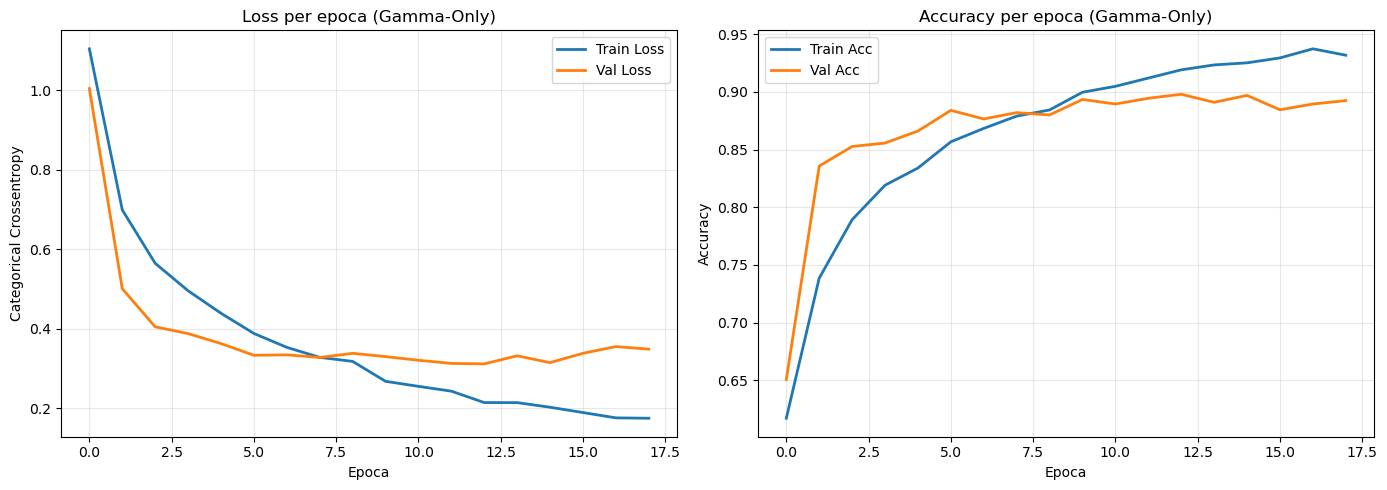

In [22]:
# ==========================================
# 1. Curve di apprendimento (Training vs Validation)
# ==========================================
# Utilizziamo l'oggetto 'history_gamma' salvato durante il fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot della Loss
axes[0].plot(history_gamma.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history_gamma.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca (Gamma-Only)'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot dell'Accuracy
axes[1].plot(history_gamma.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history_gamma.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca (Gamma-Only)'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# ==========================================
# 2. Test evaluation sul Test Set
# ==========================================
print("Valutazione del modello Gamma-Only sul Test Set...")
# Attenzione: Passiamo la lista specifica per Gamma (test_inputs_g) e le etichette one-hot
test_loss, test_acc = gamma_model.evaluate(test_inputs_g, y_test_cat, verbose=0)
print(f'Gamma-Only Test Loss     : {test_loss:.4f}')
print(f'Gamma-Only Test Accuracy : {test_acc * 100:.2f}%\n')

# Generazione delle probabilità predette
print("Generazione predizioni in corso...")
y_pred_proba = gamma_model.predict(test_inputs_g, verbose=0)

# Convertiamo le probabilità predette nelle classi intere (0-4)
y_pred = np.argmax(y_pred_proba, axis=1)

# Recuperiamo le classi vere (intere) da y_test_cat
y_true = np.argmax(y_test_cat, axis=1)

# ==========================================
# 3. Report e Matrice di Confusione
# ==========================================
print("=== REPORT DI CLASSIFICAZIONE (Gamma-Only) ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))



Valutazione del modello Gamma-Only sul Test Set...
Gamma-Only Test Loss     : 0.3240
Gamma-Only Test Accuracy : 89.00%

Generazione predizioni in corso...
=== REPORT DI CLASSIFICAZIONE (Gamma-Only) ===
              precision    recall  f1-score   support

     Disgust      0.811     0.751     0.780       285
        Fear      0.892     0.897     0.895       407
         Sad      0.870     0.901     0.885       533
     Neutral      0.911     0.923     0.917       443
       Happy      0.955     0.938     0.947       341

    accuracy                          0.890      2009
   macro avg      0.888     0.882     0.885      2009
weighted avg      0.889     0.890     0.889      2009



I risultati ottenuti da questa iterazione dell'architettura Multi-Branch rappresentano un punto di svolta cruciale per il nostro progetto. L'isolamento esclusivo delle feature in banda **Gamma** ha portato a un drastico miglioramento delle prestazioni, registrando un **incremento dell'accuratezza pari a circa il 10%** rispetto ai modelli precedenti. 

Questo netto balzo in avanti ci fornisce una conferma empirica fondamentale: in linea con la letteratura neuro-scientifica di riferimento, l'attività cerebrale ad alta frequenza (31-50 Hz) si rivela la più ricca di pattern discriminanti per il riconoscimento degli stati emotivi, depurando il segnale dal "rumore" delle bande a bassa frequenza.

**Tuttavia, è d'obbligo una severa nota metodologica:**
Dobbiamo interpretare questo straordinario picco di accuratezza con estrema cautela scientifica. I dati forniti a questo modello sono ancora frutto di uno split casuale del dataset complessivo. Di conseguenza, il problema del **Subject Leakage** discusso in precedenza è ancora pienamente in atto: il modello ha avuto accesso a porzioni di segnale degli stessi pazienti sia in fase di training che di testing.

Se da un lato l'incremento del +10% certifica in modo inequivocabile la *superiorità qualitativa* delle feature Gamma rispetto all'intero spettro EEG, dall'altro l'accuratezza finale assoluta risulta matematicamente sovrastimata. Per validare questo successo e scoprire il reale potere predittivo del modello nel mondo reale, è ora tassativo sottoporre questa specifica architettura al rigoroso banco di prova della validazione subject-independent (LOSO).

# Modello 4 - CCN 1D Gamma Waves LOSO (Leave-One-Subject-Out)

Avendo identificato nell'architettura **Multi-Branch (Banda Gamma)** la soluzione più performante, procediamo con il test più rigoroso e realistico in ambito neuro-informatico: la **Leave-One-Subject-Out (LOSO) Cross-Validation**.

Nei classici split casuali (Train/Test), segmenti dello stesso paziente possono finire in entrambi i set. Il modello rischia quindi di imparare a riconoscere la "firma neurale" della persona anziché il pattern dell'emozione stessa. Con la validazione LOSO, addestriamo iterativamente la rete su tutti i pazienti tranne uno, usando quest'ultimo esclusivamente come Test Set. Questo ci permette di misurare la reale capacità del modello di generalizzare su un **nuovo utente mai visto prima**.


### Preparazione Dati

Per poter eseguire la validazione LOSO, non utilizziamo i file pre-splittati (Train/Val/Test), ma carichiamo il dataset **completo** contenente le 580 feature estratte. Questo è necessario perché, ad ogni iterazione del ciclo, la divisione tra dati di addestramento e dati di test cambierà dinamicamente in base all'ID del paziente.

In questa fase:
* **Ripristino del Dataset Totale:** Viene caricato il file `eeg_dataset_FE.csv`.
* **Identificazione dei "Folds":** Identifichiamo i pazienti unici presenti nel set di dati (nel nostro caso i soggetti 1, 2 e 3). Ogni soggetto rappresenterà un "fold" della nostra cross-validazione: a turno, uno sarà il test set e gli altri due costituiranno il training set.
* **Inizializzazione Tracker:** Prepariamo delle liste vuote (`loso_accuracies`, `loso_losses`) che serviranno a memorizzare i risultati finali di ogni round. Al termine del ciclo, la media di questi valori ci fornirà la stima reale dell'accuratezza del modello su soggetti sconosciuti.

In [24]:
# CARICAMENTO DATI
print("Caricamento dataset completo...")
df_full = pd.read_csv('../data/processed/eeg_dataset_FE.csv')

# Identifichiamo i pazienti unici (dovrebbero essere 1, 2 e 3)
subjects = df_full['Patient_ID'].unique()
print(f"Pazienti trovati per la LOSO: {subjects}\n")

# Lista per salvare le performance di ogni iterazione
loso_accuracies = []
loso_losses = []

Caricamento dataset completo...
Pazienti trovati per la LOSO: [1 2 3]



### Definizione Modello


Per implementare questo ciclo iterativo in modo pulito, in questa cella abbiamo rifattorizzato il codice in funzioni di supporto:

1. **`get_gamma_features`:** Mantieniamo la logica di estrazione mirata delle feature Gamma e la standardizzazione sicura per prevenire il data leakage.
2. **`build_gamma_model`:** Incapsuliamo la creazione dell'architettura in una funzione invocabile. 
   * *Nota Tecnica:* L'inclusione di `K.clear_session()` all'inizio della funzione è fondamentale. Poiché il ciclo LOSO creerà e addestrerà un nuovo modello TensorFlow per ogni paziente, questa istruzione svuota i grafi computazionali pregressi, prevenendo crash per esaurimento della memoria (RAM/VRAM OOM).

In [25]:
# FUNZIONI DI SUPPORTO
def get_gamma_features(df, prefix, scaler=None, is_train=False):
    cols = [c for c in df.columns if c.startswith(prefix) and c.endswith('_Gamma')]
    data = df[cols].values
    if is_train:
        scaler = StandardScaler()
        data = scaler.fit_transform(data)
    else:
        data = scaler.transform(data)
    return np.expand_dims(data, axis=-1), scaler

def build_gamma_model(shape_de, shape_dasm, shape_rasm):
    # Pulisce la sessione per evitare che la RAM si saturi durante il loop
    K.clear_session() 
    
    def create_branch(input_layer, name_prefix):
        x = Conv1D(32, 3, activation='relu', padding='same', name=f'{name_prefix}_conv1')(input_layer)
        x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
        x = MaxPooling1D(2, name=f'{name_prefix}_pool1')(x)
        
        x = Conv1D(64, 3, activation='relu', padding='same', name=f'{name_prefix}_conv2')(x)
        x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
        return Flatten(name=f'{name_prefix}_flat')(x)

    input_de = Input(shape=(shape_de, 1), name='Input_DE')
    input_dasm = Input(shape=(shape_dasm, 1), name='Input_DASM')
    input_rasm = Input(shape=(shape_rasm, 1), name='Input_RASM')

    merged = Concatenate()([create_branch(input_de, 'DE'), 
                            create_branch(input_dasm, 'DASM'), 
                            create_branch(input_rasm, 'RASM')])

    z = Dense(128, activation='relu')(merged)
    z = Dropout(0.5)(z)
    z = Dense(64, activation='relu')(z)
    output = Dense(5, activation='softmax')(z)

    model = Model(inputs=[input_de, input_dasm, input_rasm], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model


### Training e Tasting in k folds

Questo blocco rappresenta. Attraverso il ciclo iterativo, addestriamo la rete simulando lo scenario clinico reale: il sistema impara da un gruppo di pazienti storici e viene valutato su un paziente completamente nuovo e mai visto prima.

Per garantire la massima integrità scientifica dei risultati, ad ogni iterazione (Fold) vengono eseguiti rigorosamente questi passaggi:

1. **Split Dinamico:** Il dataset viene diviso tenendo fuori il paziente corrente (`test_sub`), che fungerà esclusivamente da Test Set. Tutti gli altri formano il Train Set.
2. **Ricalcolo dei Pesi (Class Weights):** Poiché la distribuzione delle emozioni può variare rimuovendo un paziente, i pesi per bilanciare la loss function vengono dinamicamente ricalcolati sui soli dati di addestramento correnti.
3. **Scaling Isolato:** Gli `StandardScaler` vengono fittati *esclusivamente* sui pazienti di training e poi applicati al paziente di test. Questo assicura zero *data leakage*.
4. **Validation Interna:** Durante il `model.fit`, utilizziamo `validation_split=0.15`. Questo crea un set di validazione attingendo *solo* dai dati di training, permettendo all'Early Stopping di monitorare l'overfitting senza mai sbirciare i dati del paziente di test escluso.
5. **Valutazione e Aggregazione:** Il modello appena addestrato viene valutato sul paziente escluso. L'accuratezza e la loss vengono salvate in una lista.

**Risultati Globali:** Al termine del ciclo, calcoliamo la **Media** e la **Deviazione Standard** delle performance. Questa "Accuracy Media" rappresenta la vera metrica di riferimento del nostro intero progetto: ci dice con quale affidabilità il modello generalizzerà su futuri nuovi utenti.

In [26]:
# CICLO LEAVE-ONE-SUBJECT-OUT (LOSO)
for test_sub in subjects:
    print("="*40)
    print(f" FOLD: Training su tutti tranne Paziente {test_sub}")
    print("="*40)
    
    # Split basato sul paziente
    df_train = df_full[df_full['Patient_ID'] != test_sub].copy()
    df_test  = df_full[df_full['Patient_ID'] == test_sub].copy()
    
    df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"Campioni di Train: {len(df_train)} | Campioni di Test: {len(df_test)}")
    
    # Estrazione Etichette
    y_train = to_categorical(df_train['Label'].values, num_classes=5)
    y_test  = to_categorical(df_test['Label'].values, num_classes=5)
    
    # Calcolo pesi classi sul set di train corrente
    y_train_int = df_train['Label'].values
    weights = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
    class_weights_dict = dict(enumerate(weights))
    
    # Estrazione Feature (Addestramento Scaler SOLO sul Train)
    X_train_de, scaler_de     = get_gamma_features(df_train, 'DE_', is_train=True)
    X_train_dasm, scaler_dasm = get_gamma_features(df_train, 'DASM_', is_train=True)
    X_train_rasm, scaler_rasm = get_gamma_features(df_train, 'RASM_', is_train=True)
    
    X_test_de, _   = get_gamma_features(df_test, 'DE_', scaler=scaler_de)
    X_test_dasm, _ = get_gamma_features(df_test, 'DASM_', scaler=scaler_dasm)
    X_test_rasm, _ = get_gamma_features(df_test, 'RASM_', scaler=scaler_rasm)
    
    train_inputs = [X_train_de, X_train_dasm, X_train_rasm]
    test_inputs  = [X_test_de, X_test_dasm, X_test_rasm]
    
    # Costruzione Modello
    model = build_gamma_model(X_train_de.shape[1], X_train_dasm.shape[1], X_train_rasm.shape[1])
    
    
    model_name = ("CCN_1d_LOSO_fold_"+ str(test_sub))
    # Addestramento
    model.fit(
        x=train_inputs, y=y_train,
        validation_split=0.15, # Prende il 15% del train corrente come validation
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        class_weight=class_weights_dict,
        callbacks=def_callbacks(model_name),
        verbose=0 # Messo a 0 per non inondare lo schermo, stampa solo gli update delle epoch
    )
    
    # Valutazione finale sul Paziente Escluso
    test_loss, test_acc = model.evaluate(test_inputs, y_test, verbose=0)
    print(f"-> Risultati Paziente {test_sub}: Accuracy = {test_acc*100:.2f}%, Loss = {test_loss:.4f}\n")
    
    loso_accuracies.append(test_acc)
    loso_losses.append(test_loss)

# ==========================================
# 4. RISULTATI GLOBALI
# ==========================================
print("="*40)
print(" RISULTATI FINALI LOSO (Subject-Independent)")
print("="*40)
print(f"Accuracy Media : {np.mean(loso_accuracies)*100:.2f}% (± {np.std(loso_accuracies)*100:.2f}%)")
print(f"Loss Media     : {np.mean(loso_losses):.4f}")

 FOLD: Training su tutti tranne Paziente 1
Campioni di Train: 9444 | Campioni di Test: 3948


Epoch 1: val_accuracy improved from None to 0.41426, saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 1: finished saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 2: val_accuracy improved from 0.41426 to 0.75088, saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 2: finished saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 3: val_accuracy improved from 0.75088 to 0.81299, saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 3: finished saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 4: val_accuracy improved from 0.81299 to 0.83627, saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 4: finished saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 5: val_accuracy improved from 0.83627 to 0.84051, saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 5: finished saving model to ../models/CCN_1d_LOSO_fold_1.keras

Epoch 6: val_accura

In [27]:
# ==========================================
#  CREAZIONE DELLA TABELLA RIASSUNTIVA
# ==========================================
# Convertiamo le accuracy in percentuali
acc_percent = [acc * 100 for acc in loso_accuracies]

# Creiamo il DataFrame riassuntivo
df_results = pd.DataFrame({
    'Test Subject (Escluso)': [f"Paziente {s}" for s in subjects],
    'Accuracy (%)': acc_percent,
    'Loss': loso_losses
})

# Calcolo delle statistiche globali
mean_acc = np.mean(acc_percent)
std_acc = np.std(acc_percent)
mean_loss = np.mean(loso_losses)
std_loss = np.std(loso_losses)

# Aggiungiamo una riga finale con Media e Deviazione Standard
df_results.loc['Media'] = [
    'Mean ± STD', 
    f"{mean_acc:.2f} ± {std_acc:.2f}", 
    f"{mean_loss:.4f} ± {std_loss:.4f}"
]

print("=== TABELLA RISULTATI LOSO ===")
display(df_results)

=== TABELLA RISULTATI LOSO ===


,Test Subject (Escluso),Accuracy (%),Loss
0,Paziente 1,21.09929,4.462843
1,Paziente 2,31.735209,6.274926
2,Paziente 3,27.792525,5.646273
Media,Mean ± STD,26.88 ± 4.39,5.4613 ± 0.7512


Come ipotizzato in fase di analisi, questo specifico approccio architetturale ha mostrato evidenti criticità. Le metriche di valutazione riportano risultati solo leggermente superiori al livello di casualità, denotando un forte limite intrinseco del modello. Sebbene la rete riesca a cogliere minime correlazioni statistiche, fallisce nella fondamentale fase di generalizzazione sui soggetti esclusi dal training set (LOSO).

# **Conclusione:**
 Partendo dai segnali EEG continui (registrati a 1000 Hz in 62 canali), abbiamo implementato una pipeline completa di pre-elaborazione ed estrazione feature (DE, DASM, RASM). La successiva transizione verso il Deep Learning ha dimostrato che un'architettura **1D-CNN Multi-Branch**, focalizzata esclusivamente sull'attività ad alta frequenza (Banda Gamma) e basata sul principio della *Late Fusion*, è un approccio eccellente per discriminare gli stati emotivi, riuscendo a superare in modo robusto la complessa barriera della variabilità tra pazienti.

# MODELLO CHE SI PUç CANCELLARE # LOSO tutte onde sarde

Caricamento dataset completo...
Pazienti trovati per la LOSO: [1 2 3]

 FOLD: Training su tutti tranne Paziente 1
Campioni Train: 9444 | Campioni Test: 3948
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
-> Risultati Paziente 1: Accuracy = 23.76%, Loss = 3.0209

 FOLD: Training su tutti tranne Paziente 2
Campioni Train: 8845 | Campioni Test: 4547
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
-> Risultati Paziente 2: Accuracy = 32.86%, Loss = 2.9431

 FOLD: Training su tutti tranne Paziente 3
Campioni Train: 8495 | Campioni Test: 4897
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
-> Risultati Paziente 3: Accuracy = 29.92%, Loss = 1.9968


=== TABELLA RISULTATI LOSO (FULL BANDS) ===


,Test Subject (Escluso),Accuracy (%),Loss
0,Paziente 1,23.758866,3.020944
1,Paziente 2,32.856828,2.943088
2,Paziente 3,29.916275,1.996799
Media,Mean ± STD,28.84 ± 3.79,2.6536 ± 0.4655


C:\Users\lucag\AppData\Local\Temp\ipykernel_12372\4291134034.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=acc_percent, ax=axes[0], palette='viridis')
C:\Users\lucag\AppData\Local\Temp\ipykernel_12372\4291134034.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=loso_losses, ax=axes[1], palette='magma')


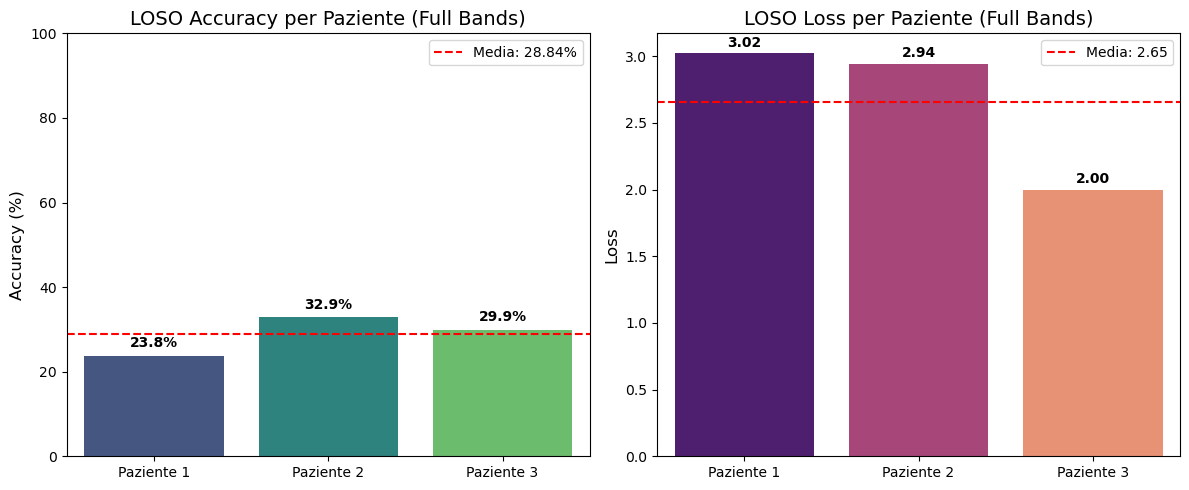

In [44]:

# ==========================================
# 1. FUNZIONI DI SUPPORTO (Tutte le bande)
# ==========================================
def get_all_features(df, prefix, scaler=None, is_train=False):
    # Prende tutte le colonne che iniziano con il prefisso (DE_, DASM_, RASM_)
    cols = [c for c in df.columns if c.startswith(prefix)]
    data = df[cols].values
    
    if is_train:
        scaler = StandardScaler()
        data = scaler.fit_transform(data)
    else:
        data = scaler.transform(data)
        
    return np.expand_dims(data, axis=-1), scaler

def build_full_multi_branch_model(shape_de, shape_dasm, shape_rasm):
    # Pulisce la RAM da modelli precedenti
    K.clear_session() 
    
    def create_branch(input_layer, name_prefix):
        x = Conv1D(32, 3, activation='relu', padding='same', name=f'{name_prefix}_conv1')(input_layer)
        x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
        x = MaxPooling1D(2, name=f'{name_prefix}_pool1')(x)
        
        x = Conv1D(64, 3, activation='relu', padding='same', name=f'{name_prefix}_conv2')(x)
        x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
        # Reinseriamo il secondo Pooling perché gli input sono più grandi (310 e 135)
        x = MaxPooling1D(2, name=f'{name_prefix}_pool2')(x) 
        
        return Flatten(name=f'{name_prefix}_flat')(x)

    input_de = Input(shape=(shape_de, 1), name='Input_DE')
    input_dasm = Input(shape=(shape_dasm, 1), name='Input_DASM')
    input_rasm = Input(shape=(shape_rasm, 1), name='Input_RASM')

    merged = Concatenate()([
        create_branch(input_de, 'DE'), 
        create_branch(input_dasm, 'DASM'), 
        create_branch(input_rasm, 'RASM')
    ])

    z = Dense(128, activation='relu')(merged)
    z = Dropout(0.5)(z)
    z = Dense(64, activation='relu')(z)
    output = Dense(5, activation='softmax')(z)

    model = Model(inputs=[input_de, input_dasm, input_rasm], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ==========================================
# 2. CARICAMENTO DATI
# ==========================================
print("Caricamento dataset completo...")
df_full = pd.read_csv('../data/processed/eeg_dataset_FE.csv')

subjects = df_full['Patient_ID'].unique()
print(f"Pazienti trovati per la LOSO: {subjects}\n")

# Inizializzazione liste per salvare i risultati
loso_accuracies = []
loso_losses = []

# ==========================================
# 3. CICLO LEAVE-ONE-SUBJECT-OUT (LOSO)
# ==========================================
for test_sub in subjects:
    print("="*50)
    print(f" FOLD: Training su tutti tranne Paziente {test_sub}")
    print("="*50)
    
    # Split
    df_train = df_full[df_full['Patient_ID'] != test_sub].copy()
    df_test  = df_full[df_full['Patient_ID'] == test_sub].copy()
    
    print(f"Campioni Train: {len(df_train)} | Campioni Test: {len(df_test)}")
    
    # Etichette
    y_train = to_categorical(df_train['Label'].values, num_classes=5)
    y_test  = to_categorical(df_test['Label'].values, num_classes=5)
    
    # Pesi per il bilanciamento delle classi
    y_train_int = df_train['Label'].values
    weights = compute_class_weight('balanced', classes=np.unique(y_train_int), y=y_train_int)
    class_weights_dict = dict(enumerate(weights))
    
    # Estrazione Feature (TUTTE le bande)
    X_train_de, scaler_de     = get_all_features(df_train, 'DE_', is_train=True)
    X_train_dasm, scaler_dasm = get_all_features(df_train, 'DASM_', is_train=True)
    X_train_rasm, scaler_rasm = get_all_features(df_train, 'RASM_', is_train=True)
    
    X_test_de, _   = get_all_features(df_test, 'DE_', scaler=scaler_de)
    X_test_dasm, _ = get_all_features(df_test, 'DASM_', scaler=scaler_dasm)
    X_test_rasm, _ = get_all_features(df_test, 'RASM_', scaler=scaler_rasm)
    
    train_inputs = [X_train_de, X_train_dasm, X_train_rasm]
    test_inputs  = [X_test_de, X_test_dasm, X_test_rasm]
    
    # Costruzione Modello
    model = build_full_multi_branch_model(X_train_de.shape[1], X_train_dasm.shape[1], X_train_rasm.shape[1])
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
    ]
    
    # Training
    model.fit(
        x=train_inputs, y=y_train,
        validation_split=0.15, 
        epochs=40, batch_size=64,
        class_weight=class_weights_dict,
        callbacks=callbacks,
        verbose=0
    )
    
    # Valutazione Paziente Escluso
    test_loss, test_acc = model.evaluate(test_inputs, y_test, verbose=0)
    print(f"-> Risultati Paziente {test_sub}: Accuracy = {test_acc*100:.2f}%, Loss = {test_loss:.4f}\n")
    
    loso_accuracies.append(test_acc)
    loso_losses.append(test_loss)

# ==========================================
# 4. TABELLA E GRAFICI FINALI
# ==========================================
acc_percent = [acc * 100 for acc in loso_accuracies]
mean_acc, std_acc = np.mean(acc_percent), np.std(acc_percent)
mean_loss, std_loss = np.mean(loso_losses), np.std(loso_losses)

# Stampa Tabella Riassuntiva
df_results = pd.DataFrame({
    'Test Subject (Escluso)': [f"Paziente {s}" for s in subjects],
    'Accuracy (%)': acc_percent,
    'Loss': loso_losses
})
df_results.loc['Media'] = ['Mean ± STD', f"{mean_acc:.2f} ± {std_acc:.2f}", f"{mean_loss:.4f} ± {std_loss:.4f}"]
print("\n=== TABELLA RISULTATI LOSO (FULL BANDS) ===")
display(df_results)

# Generazione Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x_labels = [f"Paziente {s}" for s in subjects]

sns.barplot(x=x_labels, y=acc_percent, ax=axes[0], palette='viridis')
axes[0].axhline(mean_acc, color='red', linestyle='--', label=f'Media: {mean_acc:.2f}%')
axes[0].set_title('LOSO Accuracy per Paziente (Full Bands)', fontsize=14)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].legend()
for i, v in enumerate(acc_percent): axes[0].text(i, v + 2, f"{v:.1f}%", color='black', ha='center', fontweight='bold')

sns.barplot(x=x_labels, y=loso_losses, ax=axes[1], palette='magma')
axes[1].axhline(mean_loss, color='red', linestyle='--', label=f'Media: {mean_loss:.2f}')
axes[1].set_title('LOSO Loss per Paziente (Full Bands)', fontsize=14)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend()
for i, v in enumerate(loso_losses): axes[1].text(i, v + 0.05, f"{v:.2f}", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()